In [52]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('C:/Users/rabin/sci-comp-ii-fall24/data/US_births_2000-2014_SSA.csv')
df

,year,month,date_of_month,day_of_week,births
0,2000,1,1,6,9083
1,2000,1,2,7,8006
2,2000,1,3,1,11363
3,2000,1,4,2,13032
4,2000,1,5,3,12558
...,...,...,...,...,...
5474,2014,12,27,6,8656
5475,2014,12,28,7,7724
5476,2014,12,29,1,12811
5477,2014,12,30,2,13634


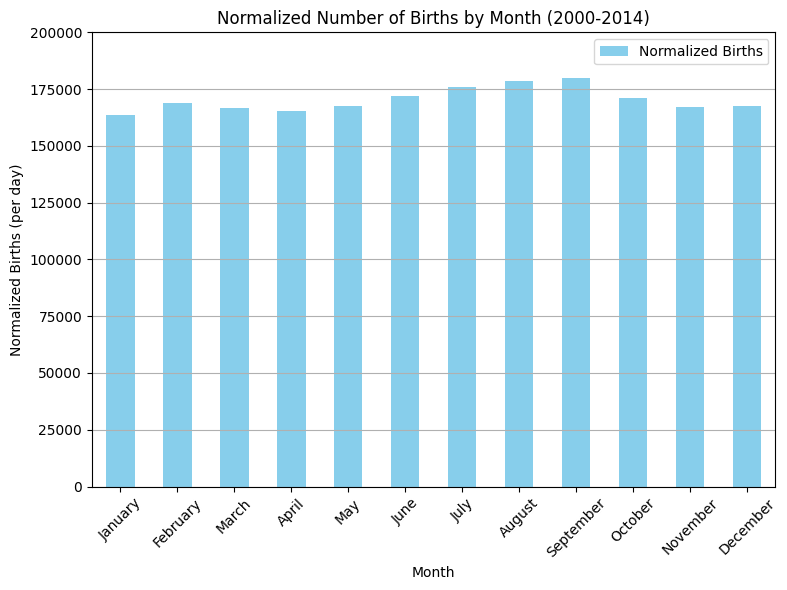

In [61]:
monthly_births = df.groupby('month')['births'].sum()

days_in_month = [31, 28, 31, 30, 31, 30, 
                 31, 31, 30, 31, 30, 31]
normalized_births = monthly_births / days_in_month

month_names = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(8, 6))
normalized_births.plot(kind='bar', color='skyblue', label='Normalized Births')
plt.title('Normalized Number of Births by Month (2000-2014)')
plt.xlabel('Month')
plt.ylabel('Normalized Births (per day)')
plt.xticks(ticks=range(12), labels=month_names, rotation=45)
plt.grid(axis='y')

plt.yticks(ticks=plt.yticks()[0])  

plt.tight_layout()
plt.legend()
plt.show()



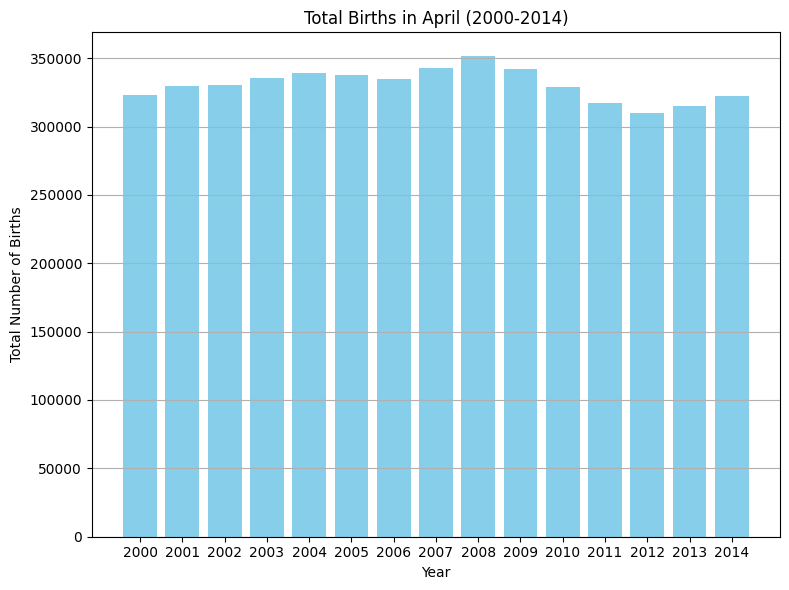

In [60]:
April_births = df[df['month'] == 4]
total_births_April = April_births.groupby('year')['births'].sum().reset_index()


plt.figure(figsize=(8, 6))
plt.bar(total_births_April['year'], total_births_April['births'], color='skyblue')
plt.title('Total Births in April (2000-2014)')
plt.xlabel('Year')
plt.ylabel('Total Number of Births')
plt.xticks(total_births_April['year'])
plt.grid(axis='y')
plt.tight_layout()
plt.show()

 Q1. I wanted to discover if the low number of births in April following normalization is a constant, universal truth. It's interesting that this was affected more severely, following the US Great Recession that started in 2008. 

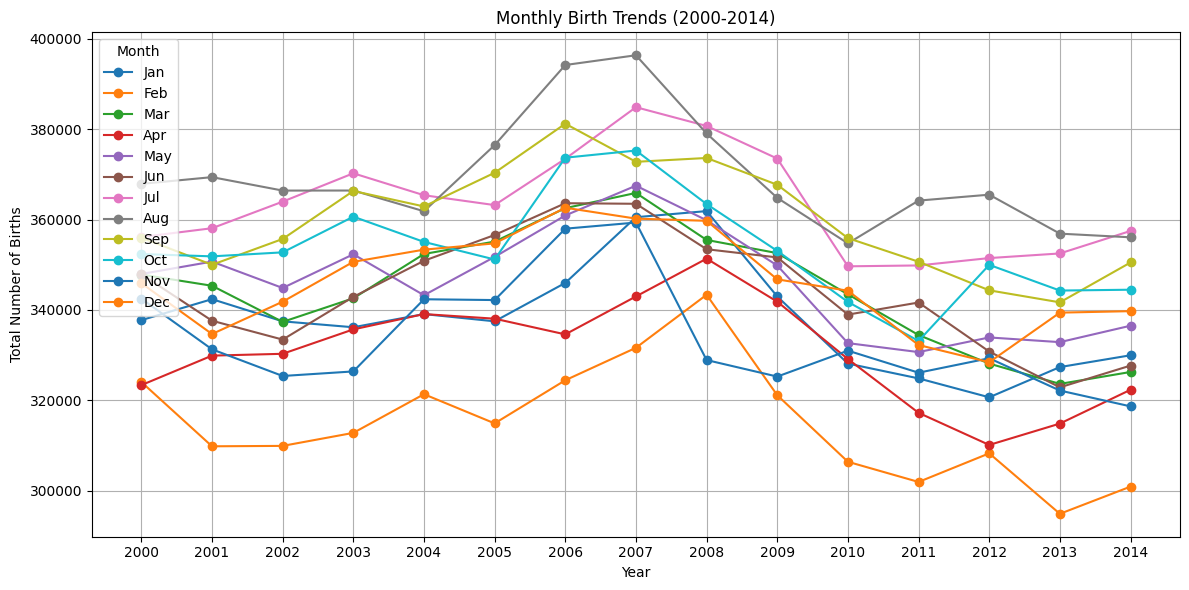

In [41]:

monthly_births = df.groupby(['year', 'month'])['births'].sum().reset_index()
monthly_births_pivot = monthly_births.pivot(index='year', columns='month', values='births')


plt.figure(figsize=(12, 6))
for month in range(1, 13):
    plt.plot(monthly_births_pivot.index, monthly_births_pivot[month], marker='o', label=month)

plt.title('Monthly Birth Trends (2000-2014)')
plt.xlabel('Year')
plt.ylabel('Total Number of Births')
plt.xticks(monthly_births_pivot.index)
plt.legend(title='Month', labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()
